# Load factor control

{download}`Download <frame-1010.ipynb>`

In [1]:
#
# Hockling problem, as desribed by Perez and Filippou (2024).
#
# https://onlinelibrary.wiley.com/doi/10.1002/nme.7506
#
from xara.benchmarks import Prism
import xara
from shps.rotor import exp
import numpy as np
import veux
import matplotlib.pyplot as plt


ne = 20
E  = 71_240
G  = 27_190
I  = 0.0833
A  = 10.0
J  = 2.16
L  = 240.0

def create_model(element):
    prism = Prism(
        length = L,
        element = element,
        material = dict(
            E   = E,
            G   = G,
        ),
        shape   = dict(
            A   = A,
            J   = J,
            Iy  = I,
            Iz  = I,
            Ay  = A,
            Az  = A),
        boundary = ((1,1,1, 1,1,1),
                    (0,1,1, 0,1,1)),
        transform = "Corotational02",
        divisions = ne,
        rotation = exp([0,  0.0, 0.005])
    )

    return prism.create_model()

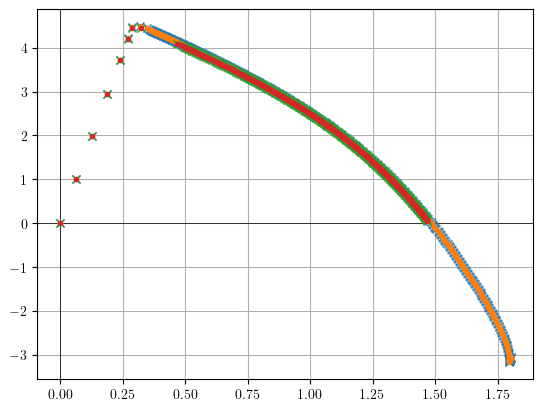

In [3]:


fig, ax = plt.subplots()
ax.grid("on")
ax.axvline(0, color='k', lw=0.5)
ax.axhline(0, color='k', lw=0.5)

for element in ["ExactFrame", "ForceFrame"]:
    model = create_model(element)

    #
    # Analysis
    #
    scale = 5 #0.0
    steps = 65
    Tref  = 2*E*I/L

    f = [0, 0, 0] + list(map(float, [Tref, 0, 0]))
    model.pattern("Plain", 1, "Linear", load={
        ne+1: f
    })

    analysis = xara.StaticAnalysis(model, 
                                   test=("NormDispIncr", 1e-9, 52, 0),
                                   integrator=("MinUnbalDispNorm", 1, 5,  1/steps/1000, 1),
                                   system="BandGeneral")

    u = []
    lam = []
    time = []

    for i in range(400):
        u.append(model.nodeDisp(ne+1, 4)/np.pi)
        time.append(model.getTime())
        lam.append(model.getLoadFactor(1))
        analysis.analyze()

#       artist.draw_outlines(state=model.nodeDisp)

    ax.plot(u, lam,  'x')
    ax.plot(u, time, '.')



